# Larissa CMIP6 SSP2-4.5 Projection EDA (2026-2045)

Ports `larissa_cmip6_projection_eda.ipynb` (the SSP5-8.5 notebook, itself Larissa's version of
`seville_cmip6_projection_eda.ipynb`) to the CMIP6 `cmcc_esm2` SSP2-4.5 projection pulled by
`pull_cmip6_projections_ssp245.py`. Same model as SSP5-8.5, deliberately -- see
`seville_cmip6_projection_eda.ipynb`'s SSP2-4.5 intro for why -- so this notebook's bias correction
(Section 12) reuses the existing `cmcc_esm2` historical run (1990-2014, already pulled for the
SSP5-8.5 notebooks) rather than requiring a second historical pull.

**Source data:** `data/larissa_cmip6_ssp245_2026_2045.csv` (model `cmcc_esm2`, experiment `ssp2_4_5`,
6 grid points in the Larissa bounding box, 2026-01-01 to 2045-12-31).

**Historical reference:** `../../Historical/eda_outputs/larissa/larissa_daily.csv`, `annual_summary.csv`,
`larissa_climate_indicators_annual.csv`, and `larissa_volatility_annual.csv`, from `larissa_era5_eda.ipynb`
and the Larissa climate-indicators/volatility work.

**What's different from the Seville SSP2-4.5 notebook**, mirroring how the SSP5-8.5 Larissa notebook
differs from its Seville counterpart (see this notebook's own Section 17): Larissa's headline
indicators are `tmin_mean` (chronic warming) and `max_week_precip_mm` (flood-peak intensity) rather
than Seville's `tmax_mean`/heat-index/fire-danger set, and there is no fire-danger (FWI) indicator for
Larissa at all -- confirmed in the SSP5-8.5 notebook's own Section 17 ("no Larissa-side FWI validation
exists"), so no Larissa FWI projection notebook is being built either, unlike Seville's.

**Known limitations, as with the Seville notebook:** raw (non-bias-corrected) CMIP6 output at a single
grid box, one model, one scenario. Sections 1-11 work entirely with raw output; Section 12 applies an
Equidistant CDF Matching bias correction, and Sections 13-16 recompute every indicator on that
corrected series with an explicit before/after comparison. This version's Section 17 additionally
notes that the `min_spi3` supplementary drought panel present in the SSP5-8.5 notebook is deferred
here pending `Calculating_SPI_for_Larissa_Projection.ipynb`'s SSP2-4.5 port.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)

RAW_CSV = Path("../data/larissa_cmip6_ssp245_2026_2045.csv")
ERA5_DAILY_CSV = Path("../../Historical/eda_outputs/larissa/larissa_daily.csv")
ERA5_ANNUAL_CSV = Path("../../Historical/eda_outputs/larissa/annual_summary.csv")
ERA5_INDICATORS_CSV = Path("../../Historical/eda_outputs/larissa/larissa_climate_indicators_annual.csv")
OUT = Path("../eda_outputs/larissa")
OUT.mkdir(parents=True, exist_ok=True)

# Fixed reference period -- used only to fit thresholds below, never refit on new data.
# See fixed_reference_period_principle.md.
REFERENCE_START, REFERENCE_END = 1990, 2020


## 1. Load the raw CMIP6 pull

Identical QC step to `seville_cmip6_projection_eda.ipynb` Section 1 -- `pull_cmip6_projections.py`
merges 7 separately-downloaded variables on `(valid_time, lat, lon)`, each carrying its own 2-valued
`bnds` dimension that isn't part of the merge key. Dropped explicitly below, as a documented QC step
(same reasoning as Seville's version -- not repeated here).


In [2]:
raw = pd.read_csv(RAW_CSV, parse_dates=["valid_time"])
print(f"raw shape: {raw.shape}")
print(raw.columns.tolist())

BNDS_COLS = ["bnds", "time_bnds", "lat_bnds", "lon_bnds", "height"]
df = raw.drop(columns=[c for c in BNDS_COLS if c in raw.columns]).drop_duplicates().reset_index(drop=True)

n_days = df["valid_time"].nunique()
n_points = df[["lat", "lon"]].drop_duplicates().shape[0]
print(f"deduped shape: {df.shape}  (expected {n_days} days x {n_points} grid points = {n_days * n_points})")
assert df.shape[0] == n_days * n_points, "dedup did not fully resolve the bnds cross-join"
df.head()


raw shape: (43800, 12)
['valid_time', 'lat', 'lon', 'tas', 'tasmax', 'tasmin', 'pr', 'huss', 'sfcWind', 'psl', 'precip_mm_day', 'relative_humidity_pct']
deduped shape: (43800, 12)  (expected 7300 days x 6 grid points = 43800)


,valid_time,lat,lon,tas,tasmax,tasmin,pr,huss,sfcWind,psl,precip_mm_day,relative_humidity_pct
0,2026-01-01,39.109948,21.25,281.23587,282.32812,279.12515,0.000082,0.005457,3.272291,100987.100,7.048388,81.934120
1,2026-01-01,39.109948,22.50,280.05377,281.35968,278.95645,0.000059,0.005461,1.676398,101071.010,5.058661,88.961205
2,2026-01-01,39.109948,23.75,283.71094,285.21216,283.07996,0.000045,0.005228,4.564134,101007.516,3.894270,66.491280
3,2026-01-01,40.052356,21.25,278.16165,279.43820,276.29730,0.000135,0.004938,2.338230,100930.945,11.700412,91.565384
4,2026-01-01,40.052356,22.50,277.38745,278.60614,276.14444,0.000060,0.004379,1.817292,101117.620,5.141586,85.899950


## 2. Physical plausibility check

Same bounds as Seville's version -- these are CMIP6-native ranges (Kelvin temperatures, flux-unit
precip, Pa pressure), not city-specific, so they carry over unchanged.


In [3]:
BOUNDS = {
    "tas": (250, 325), "tasmax": (250, 330), "tasmin": (245, 320),
    "pr": (0, 0.005),           # kg m-2 s-1 -- 0.005 corresponds to ~430 mm/day, a generous upper bound
    "huss": (0, 0.03),
    "sfcWind": (0, 40),
    "psl": (90000, 108000),
    "precip_mm_day": (0, 400),
    "relative_humidity_pct": (0, 100),
}
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    n_bad = (~df[col].between(lo, hi)).sum()
    print(f"{col:24s} range=({df[col].min():.4g}, {df[col].max():.4g})  out-of-bounds={n_bad}")

# precip_mm_day carries tiny floating-point negative noise from the flux conversion at near-zero
# rainfall -- clip rather than treat it as a QC failure (same artifact documented in Seville's
# version of this check).
df["precip_mm_day"] = df["precip_mm_day"].clip(lower=0)


tas                      range=(259.6, 311.2)  out-of-bounds=0
tasmax                   range=(264.2, 318.4)  out-of-bounds=0
tasmin                   range=(254.3, 307.7)  out-of-bounds=0
pr                       range=(-1.795e-21, 0.0007943)  out-of-bounds=80
huss                     range=(0.00134, 0.02095)  out-of-bounds=0
sfcWind                  range=(0.3165, 14.6)  out-of-bounds=0
psl                      range=(9.887e+04, 1.048e+05)  out-of-bounds=0
precip_mm_day            range=(-1.551e-16, 68.63)  out-of-bounds=80
relative_humidity_pct    range=(10.58, 100)  out-of-bounds=0


## 3. Unit conversions

Same `- 273.15` Kelvin-to-Celsius conversion as Seville. Precipitation, specific humidity, wind
speed, and relative humidity are already in final units/derived form upstream.


In [4]:
df["tas_c"] = df["tas"] - 273.15
df["tasmax_c"] = df["tasmax"] - 273.15
df["tasmin_c"] = df["tasmin"] - 273.15
df[["tas_c", "tasmax_c", "tasmin_c"]].describe()


,tas_c,tasmax_c,tasmin_c
count,43800.000000,43800.000000,43800.000000
mean,17.597283,20.813713,14.272393
std,8.678337,9.287616,8.345917
min,-13.533330,-8.958440,-18.889470
25%,10.863260,13.541163,7.984235
50%,16.417520,19.377765,13.667130
75%,25.004413,28.370058,21.293050
max,38.072470,45.296320,34.510740


## 4. Grid-point averaging (grid points to 1 daily series)

Same unweighted arithmetic mean as Seville's version, and the same discipline of recomputing RH from
grid-averaged `tas`/`huss`/`psl` (Magnus-formula) rather than averaging RH directly.


In [5]:
BASE = ["tas", "tasmax", "tasmin", "tas_c", "tasmax_c", "tasmin_c",
        "precip_mm_day", "sfcWind", "huss", "psl"]

lar = df.groupby("valid_time")[BASE].mean()

def derive_rh(tas_k, huss, psl_pa):
    """Identical formula to pull_cmip6_projections.py's per-grid-point derivation, applied here
    to the grid-averaged base variables instead."""
    t_c = tas_k - 273.15
    p_hpa = psl_pa / 100.0
    q = huss
    vapor_pressure = q * p_hpa / (0.622 + 0.378 * q)
    sat_vapor_pressure = 6.112 * np.exp(17.62 * t_c / (243.12 + t_c))
    return np.clip(100 * vapor_pressure / sat_vapor_pressure, 0, 100)

lar["relative_humidity_pct"] = derive_rh(lar["tas"], lar["huss"], lar["psl"])
lar.head()


,tas,tasmax,tasmin,tas_c,tasmax_c,tasmin_c,precip_mm_day,sfcWind,huss,psl,relative_humidity_pct
valid_time,,,,,,,,,,,
2026-01-01,280.221192,281.638253,278.885940,7.071192,8.488253,5.735940,6.331601,2.999521,0.004994,101027.488500,80.418066
2026-01-02,279.403593,281.705678,276.250353,6.253593,8.555678,3.100353,4.100966,5.863318,0.004589,100411.494167,77.707028
2026-01-03,275.185058,276.655862,273.421177,2.035058,3.505862,0.271177,0.101758,5.640631,0.002937,101932.715000,67.909643
2026-01-04,275.517230,278.171637,273.122172,2.367230,5.021637,-0.027828,0.010175,3.416610,0.003071,103239.639167,70.234891
2026-01-05,280.455228,284.168907,276.336428,7.305228,11.018907,3.186428,0.001025,4.037208,0.004744,103234.786667,76.827276


## 5. Daily frame

Same as Seville: CMIP6 provides true daily `tasmax`/`tasmin` natively, so `lar` (indexed by
`valid_time`, one row per day) *is* the daily frame -- no resampling step. Columns renamed to match
`larissa_era5_eda.ipynb`'s naming convention.

Same caveat as Seville's version applies: `heat_index_c` here is computed once per day from daily-mean
T/RH, not (as in the ERA5 pipeline) the max of intra-day samples -- named differently from the
historical `heat_index_max_c` for that reason.


In [6]:
def compute_heat_index(t_c, rh):
    """Identical NWS Rothfusz fit used throughout the project (degF internally, converted back to degC)."""
    t_f = t_c * 9 / 5 + 32
    simple = 0.5 * (t_f + 61.0 + (t_f - 68.0) * 1.2 + rh * 0.094)
    hi_f = (-42.379 + 2.04901523 * t_f + 10.14333127 * rh - 0.22475541 * t_f * rh - 6.83783e-3 * t_f**2
            - 5.481717e-2 * rh**2 + 1.22874e-3 * t_f**2 * rh + 8.5282e-4 * t_f * rh**2 - 1.99e-6 * t_f**2 * rh**2)
    return (np.where(t_f < 80, simple, hi_f) - 32) * 5 / 9

daily = pd.DataFrame({
    "tmax_c": lar["tasmax_c"],
    "tmin_c": lar["tasmin_c"],
    "tmean_c": lar["tas_c"],
    "precip_mm_day": lar["precip_mm_day"],
    "wind_avg": lar["sfcWind"],
    "rh_mean_percent": lar["relative_humidity_pct"],
})
daily["dtr_c"] = daily["tmax_c"] - daily["tmin_c"]
daily["heat_index_c"] = compute_heat_index(daily["tmean_c"], daily["rh_mean_percent"])
daily["year"] = daily.index.year
daily["month"] = daily.index.month

daily.to_csv(OUT / "larissa_projection_daily.csv")
daily.describe()


,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,20.813713,14.272393,17.597283,1.385928,2.916314,62.437058,6.541320,17.005115,2035.500000,6.526027
std,9.081576,7.944285,8.516604,3.224540,1.001491,17.317173,2.043157,8.986297,5.766676,3.448088
min,-3.400418,-7.545238,-4.710863,0.000000,0.978044,25.376397,1.060815,-6.599529,2026.000000,1.000000
25%,13.513169,7.947893,10.819347,0.001583,2.170520,48.203260,5.123174,9.899592,2030.750000,4.000000
50%,19.359112,13.176055,16.208715,0.120470,2.740259,63.832700,6.649140,15.658253,2035.500000,7.000000
75%,28.742664,21.291471,25.089264,1.106249,3.481009,76.146114,8.032404,24.949964,2040.250000,10.000000
max,40.529703,31.526237,35.557083,46.941803,8.332332,100.000000,12.149053,36.438980,2045.000000,12.000000


## 6. Fixed reference-period thresholds (loaded from ERA5, 1990-2020, never refit here)

Same reasoning as Seville Section 6: the P90 heatwave threshold is computed once from Larissa's own
ERA5 historical daily series, restricted to the fixed 1990-2020 reference period, and never refit on
projection data (`fixed_reference_period_principle.md`).


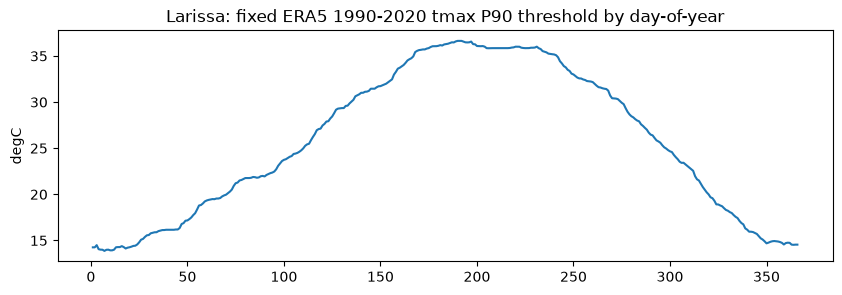

In [7]:
era5_daily = pd.read_csv(ERA5_DAILY_CSV, parse_dates=["valid_time"])
era5_daily["year"] = era5_daily["valid_time"].dt.year
ref = era5_daily[era5_daily["year"].between(REFERENCE_START, REFERENCE_END)].copy()
ref["doy"] = ref["valid_time"].dt.dayofyear

tmax_p90_by_doy = {}
for doy in range(1, 367):
    window = [((doy - 1 + k) % 366) + 1 for k in range(-7, 8)]
    tmax_p90_by_doy[doy] = ref.loc[ref["doy"].isin(window), "tmax_c"].quantile(0.90)

pd.Series(tmax_p90_by_doy).plot(
    title="Larissa: fixed ERA5 1990-2020 tmax P90 threshold by day-of-year", figsize=(10, 3))
plt.ylabel("degC")
plt.show()


## 7. Indicator calculation

Same fixed thresholds and >=3-consecutive-day heatwave-run requirement as Seville's version.


In [8]:
THRESH = [30, 33, 35, 37, 40]

d = daily.copy()
d["doy"] = d.index.dayofyear
d["tmax_p90"] = d["doy"].map(tmax_p90_by_doy)
d["exceed"] = d["tmax_c"] > d["tmax_p90"]

grp = (d["exceed"] != d["exceed"].shift()).cumsum()
runs = (d[d["exceed"]]
        .groupby(grp[d["exceed"]])
        .agg(start=("tmax_c", lambda s: s.index.min()),
             length=("tmax_c", "size"),
             peak=("tmax_c", "max"),
             mean_tmax=("tmax_c", "mean")))
heatwaves = runs[runs["length"] >= 3].reset_index(drop=True)
heatwaves["year"] = pd.to_datetime(heatwaves["start"]).dt.year
heatwaves.to_csv(OUT / "larissa_projection_heatwave_events.csv", index=False)

hot = pd.DataFrame({
    f"days tmax>={t} C": d.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot["tropical nights tmin>=20 C"] = d.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum()))
hot["days heat index>=35 C"] = d.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum()))

hw_year = heatwaves.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"{len(heatwaves)} heatwave events detected, {heatwaves['year'].nunique()} distinct years")
hot.tail()


80 heatwave events detected, 18 distinct years


,days tmax>=30 C,days tmax>=33 C,days tmax>=35 C,days tmax>=37 C,days tmax>=40 C,tropical nights tmin>=20 C,days heat index>=35 C
year,,,,,,,
2041,67,47,33,15,0,110,0
2042,79,35,11,1,0,95,0
2043,98,59,38,14,2,113,1
2044,93,59,37,21,0,132,6
2045,96,62,35,7,0,115,0


## 8. Wet-day and precipitation extremes, including `max_week_precip_mm`

Same wet-day/dry-spell logic as Seville's version, **plus one addition Seville's pipeline never
needed**: `max_week_precip_mm` (annual maximum single-week precipitation total) -- Larissa's
flood-intensity indicator, identical construction to `Calculating_SPI_for_Larissa.ipynb` Section 6
(`precip_mm_day`, resampled to weekly sums, then the annual max, labeled by the year the week falls
in), just applied to the CMIP6 daily series instead of ERA5's.


In [9]:
WET = 1.0
d["is_wet"] = d["precip_mm_day"] >= WET

def max_dry_run(is_wet):
    dry_flag = (~is_wet).astype(int)
    run_id = (is_wet != is_wet.shift()).cumsum()
    return int(dry_flag.groupby(run_id).sum().max())

def annual_max_week_precip(frame, precip_col="precip_mm_day"):
    """Same construction as Calculating_SPI_for_Larissa.ipynb Section 6: weekly-resampled sum,
    then the annual max, labeled by the calendar year the week falls in."""
    weekly = frame[precip_col].resample("W").sum()
    weekly_year = weekly.index.to_series().apply(lambda ts: ts.year)
    return weekly.groupby(weekly_year).max().rename("max_week_precip_mm").rename_axis("year")

wetstats = d.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)

max_week_precip = annual_max_week_precip(daily)
wetstats.tail()


,wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days)
year,,,,,
2041,95.0,4.864388,18.195152,13.729715,38.0
2042,99.0,4.297454,20.366223,12.376330,20.0
2043,67.0,5.042466,24.271463,14.783175,35.0
2044,90.0,4.153211,27.523305,9.657118,26.0
2045,87.0,4.275115,17.742427,11.671470,33.0


## 9. Annual summary and export

Same shape as Seville's Section 9, plus `max_week_precip_mm` joined in as a new column.


In [10]:
annual = pd.DataFrame({
    "tas_mean": d.groupby("year")["tmean_c"].mean(),
    "rh_mean": d.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d.groupby("year")["wind_avg"].mean(),
    "tas_p95": d.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d.groupby("year")["tmin_c"].mean(),
    "precip_total": d.groupby("year")["precip_mm_day"].sum(),
})

annual_summary = (annual.join(hot, how="left").join(hw_year, how="left")
                   .join(wetstats, how="left").join(max_week_precip, how="left"))
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary[col] = annual_summary[col].fillna(0).astype(int)

annual_summary.to_csv(OUT / "larissa_projection_annual_summary.csv")
annual_summary


,tas_mean,rh_mean,heat_index_mean,wind_mean,tas_p95,tas_p05,tmax_mean,tmin_mean,precip_total,days tmax>=30 C,...,days heat index>=35 C,heatwaves,heatwave days,longest (days),wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days),max_week_precip_mm
year,,,,,,,,,,,,,,,,,,,,,
2026,16.851838,64.647834,16.262464,2.842162,29.605984,3.630089,19.960958,13.629622,603.926883,65,...,0,0,0,0,107.0,5.249815,18.177341,13.503788,36.0,66.031176
2027,16.694582,65.177875,16.098651,2.874774,30.251701,4.330905,19.900621,13.412422,552.681760,70,...,0,4,14,4,105.0,4.872331,34.253048,12.039737,26.0,60.109414
2028,16.978275,63.344362,16.330843,2.941882,30.310031,6.004966,20.305963,13.493150,444.386704,72,...,0,0,0,0,92.0,4.393223,16.207509,11.310047,29.0,34.564308
2029,16.975817,60.442326,16.220984,2.880590,30.964817,4.243032,20.417366,13.457257,391.858920,78,...,0,1,3,3,68.0,5.165268,22.761617,12.702514,25.0,43.096264
2030,16.406531,61.161648,15.611878,3.094970,30.399436,2.644922,19.516944,13.135556,561.246895,72,...,0,4,15,4,94.0,5.541552,27.381409,17.940230,61.0,74.805877
2031,16.838299,66.380418,16.315686,2.981597,29.966910,2.444513,19.754487,13.812335,754.537300,48,...,0,1,3,3,129.0,5.628443,38.989214,17.488519,43.0,61.589607
2032,17.517316,59.896599,16.820269,2.900753,31.440734,4.506281,21.204286,13.816076,334.444136,103,...,0,9,35,7,65.0,4.561867,23.463480,15.386732,41.0,40.691131
2033,17.896927,61.586741,17.272428,2.893239,31.967763,6.113686,21.052691,14.596182,550.483614,92,...,0,4,21,9,94.0,5.409531,46.941803,13.666496,45.0,56.867848
2034,17.459774,63.034236,16.850673,2.909563,31.169249,5.849733,20.541015,14.265369,486.803148,76,...,0,3,11,4,92.0,4.769517,42.039944,12.305549,35.0,73.747951


## 10. Trend within the projection period (2026-2045)

Same `trend_table()` as Seville's version. `TREND_COLS` is adapted to Larissa's own headline set --
`tmin_mean` (chronic warming) and `max_week_precip_mm` (flood-peak intensity) are included prominently
alongside the shared indicators, rather than `tmax_mean`/the heat-index columns Seville emphasizes.


In [11]:
def trend_table(frame, cols, per_decade=True):
    scale = 10.0 if per_decade else 1.0
    x = frame.index.values.astype(float)
    rows = []
    for c in cols:
        y = frame[c].values.astype(float)
        lr = stats.linregress(x, y)
        ts_slope, ts_int, ts_lo, ts_hi = stats.theilslopes(y, x, 0.95)
        tau, tau_p = stats.kendalltau(x, y)
        rows.append({
            "variable": c,
            "OLS slope/decade": lr.slope * scale,
            "OLS p-value": lr.pvalue,
            "Theil-Sen slope/decade": ts_slope * scale,
            "Theil-Sen 95% CI low": ts_lo * scale,
            "Theil-Sen 95% CI high": ts_hi * scale,
            "Kendall tau": tau,
            "tau p-value": tau_p,
            "significant (p<0.05)": lr.pvalue < 0.05,
        })
    return pd.DataFrame(rows).set_index("variable")

TREND_COLS = ["tas_mean", "tmin_mean", "tmax_mean", "heat_index_mean", "precip_total", "max_week_precip_mm"]
proj_trends = trend_table(annual_summary, TREND_COLS)
proj_trends.to_csv(OUT / "larissa_projection_trends.csv")
proj_trends


,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% CI low,Theil-Sen 95% CI high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
tas_mean,0.941773,0.000354,0.919079,0.534650,1.360354,0.526316,0.000841,True
tmin_mean,0.941118,0.000229,0.921729,0.551755,1.346464,0.557895,0.000359,True
tmax_mean,0.943987,0.001026,0.986180,0.494932,1.548008,0.473684,0.002994,True
heat_index_mean,1.022161,0.000250,0.974418,0.613090,1.481768,0.557895,0.000359,True
precip_total,-44.444743,0.339446,-68.613252,-126.986696,28.550452,-0.231579,0.164976,False
max_week_precip_mm,-5.697168,0.398163,-5.546159,-18.014640,6.999717,-0.168421,0.318896,False


## 11. Comparing the projection against the ERA5 historical baseline

`Climate_Indicators_Modeling_Larissa.ipynb`'s Section 10 sketched this comparison in prose, before the
projection pull existed: extrapolate the Larissa-recommended `tmin_mean` model (`ols_last_15yr`, fit
on 2011-2025) forward through 2026-2045, and compare it against the CMIP6 projection's own `tmin_mean`
for the same years -- identical logic to Seville's `tmax_mean`/`ols_last_20yr` comparison, just with
Larissa's own recommended indicator and window (`tmin_mean` is Larissa's most robust result across
every CV split tested in that notebook, the role `tmax_mean` plays for Seville).


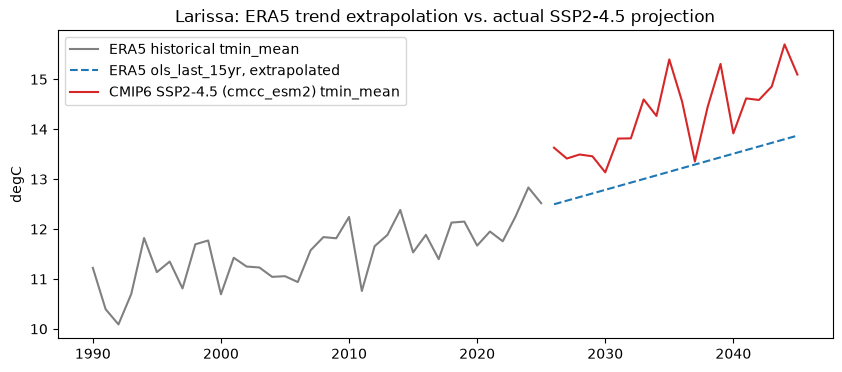

Mean gap 2026-2045: +1.09 degC (positive = SSP2-4.5 projection warmer than the historical-trend extrapolation)


,cmip6_tmin_mean,era5_ols_last15yr_extrapolated,gap_c
year,,,
2026,13.629622,12.495738,1.133884
2027,13.412422,12.568133,0.844289
2028,13.493150,12.640527,0.852624
2029,13.457257,12.712921,0.744336
2030,13.135556,12.785315,0.350241
2031,13.812335,12.857709,0.954626
2032,13.816076,12.930104,0.885972
2033,14.596182,13.002498,1.593684
2034,14.265369,13.074892,1.190477


In [12]:
era5_annual = pd.read_csv(ERA5_ANNUAL_CSV, index_col="year")
last15 = era5_annual.loc[2011:2025, "tmin_mean"]
lr = stats.linregress(last15.index.values.astype(float), last15.values.astype(float))

proj_years = annual_summary.index.values.astype(float)
era5_extrapolated = lr.intercept + lr.slope * proj_years

comparison = pd.DataFrame({
    "cmip6_tmin_mean": annual_summary["tmin_mean"],
    "era5_ols_last15yr_extrapolated": era5_extrapolated,
}, index=annual_summary.index)
comparison["gap_c"] = comparison["cmip6_tmin_mean"] - comparison["era5_ols_last15yr_extrapolated"]
comparison.to_csv(OUT / "larissa_projection_vs_era5_extrapolation.csv")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(era5_annual.index, era5_annual["tmin_mean"], label="ERA5 historical tmin_mean", color="gray")
ax.plot(proj_years, era5_extrapolated, "--", label="ERA5 ols_last_15yr, extrapolated", color="tab:blue")
ax.plot(proj_years, annual_summary["tmin_mean"], label="CMIP6 SSP2-4.5 (cmcc_esm2) tmin_mean", color="tab:red")
ax.set_ylabel("degC")
ax.set_title("Larissa: ERA5 trend extrapolation vs. actual SSP2-4.5 projection")
ax.legend()
plt.show()

print(f"Mean gap 2026-2045: {comparison['gap_c'].mean():+.2f} degC "
      f"(positive = SSP2-4.5 projection warmer than the historical-trend extrapolation)")
comparison


## 12. Bias-correcting the projection against ERA5 (Equidistant CDF Matching)

Same methodology as Seville Section 12 -- Equidistant CDF Matching (Li, Sheffield & Wood 2010),
fit on the 1990-2014 CMIP6-historical-vs-ERA5-observed overlap, additive for temperature/wind/RH,
multiplicative for precipitation (guards against pushing near-zero days negative). Applied only to
this notebook's own 2026-2045 series, via the same shared `cmip6_grid_processing.py` /
`bias_correct_cmip6_projection.py` helpers Seville's version imports -- not re-derived here.

Larissa's own bias direction isn't assumed to match Seville's -- the diagnostics below are computed
fresh from Larissa's own ERA5-vs-`cmcc_esm2` overlap, not copied from Seville's numbers.


In [13]:
import sys
sys.path.insert(0, "../../scripts")
from bias_correct_cmip6_projection import (
    _empirical_cdf, _value_to_quantile, _quantile_to_value, VARIABLE_MAP, REF_START, REF_END,
)
from cmip6_grid_processing import grid_average_daily

CMIP6_HISTORICAL_CSV = Path("../../Projected_SSP5-8.5/data/larissa_cmip6_historical_1990_2014.csv")  # reused: same model, historical run is scenario-independent

era5_ref_bc = era5_daily[era5_daily["year"].between(REF_START, REF_END)]
model_hist = grid_average_daily(CMIP6_HISTORICAL_CSV)
model_hist_ref = model_hist[model_hist["year"].between(REF_START, REF_END)]

corrected = daily.copy()
bc_diagnostics = []

for model_col, (era5_col, kind) in VARIABLE_MAP.items():
    if model_col not in daily.columns:
        # rh_min_percent (added upstream for the FWI pipeline, see cmip6_grid_processing.py) has
        # no equivalent in this notebook's hand-built `daily` frame (Section 5 only carries the
        # variables this notebook itself uses downstream) -- skip rather than KeyError. FWI-related
        # work lives in FWI_projections_2026_2045.ipynb, not here.
        continue
    for month in range(1, 13):
        obs_vals = era5_ref_bc.loc[era5_ref_bc["month"] == month, era5_col]
        hist_vals = model_hist_ref.loc[model_hist_ref["month"] == month, model_col]
        fut_mask = daily["month"] == month
        fut_vals = daily.loc[fut_mask, model_col]

        obs_probs, obs_q = _empirical_cdf(obs_vals)
        hist_probs, hist_q = _empirical_cdf(hist_vals)

        tau = np.clip(_value_to_quantile(fut_vals.values, hist_probs, hist_q), 0.0, 1.0)
        obs_at_tau = _quantile_to_value(tau, obs_probs, obs_q)
        hist_at_tau = _quantile_to_value(tau, hist_probs, hist_q)

        if kind == "additive":
            new_vals = fut_vals.values + (obs_at_tau - hist_at_tau)
        else:  # multiplicative -- guards against blow-up when hist_at_tau is near zero
            ratio = np.clip(obs_at_tau / np.clip(hist_at_tau, 1e-3, None), 0.1, 10.0)
            new_vals = np.clip(fut_vals.values * ratio, 0, None)

        corrected.loc[fut_mask, model_col] = new_vals
        bc_diagnostics.append({
            "variable": model_col,
            "month": month,
            "mean_bias_hist_vs_obs": float(hist_vals.mean() - obs_vals.mean()),
            "mean_correction_applied": float(np.mean(new_vals - fut_vals.values)),
        })

# heat_index_c and dtr_c are derived from tmean_c/tmax_c/tmin_c/rh_mean_percent -- recompute both
# from the now-corrected inputs so Sections 13-16 below aren't silently working off stale numbers.
corrected["dtr_c"] = corrected["tmax_c"] - corrected["tmin_c"]
corrected["heat_index_c"] = compute_heat_index(corrected["tmean_c"], corrected["rh_mean_percent"])

bc_diag_df = pd.DataFrame(bc_diagnostics)
bc_diag_df.to_csv(OUT / "larissa_projection_bias_correction_diagnostics_2026_2045.csv", index=False)
corrected.to_csv(OUT / "larissa_projection_daily_biascorrected_2026_2045.csv")

mean_tmin_correction = bc_diag_df.loc[bc_diag_df["variable"] == "tmin_c", "mean_correction_applied"].mean()
print(f"mean tmin_c correction applied (2026-2045): {mean_tmin_correction:+.3f} degC")
corrected.describe()


mean tmin_c correction applied (2026-2045): -1.639 degC


,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,22.267720,12.633691,16.673841,1.407433,1.564433,64.057880,9.634029,16.092580,2035.500000,6.526027
std,9.051976,7.731716,8.257919,4.459765,0.602103,14.577568,2.544407,8.888142,5.766676,3.448088
min,-5.591243,-17.378490,-13.480032,0.000000,0.428024,19.728140,-0.107225,-16.651483,2026.000000,1.000000
25%,14.487586,6.384628,9.599173,0.000164,1.191086,52.706084,7.940732,8.599015,2030.750000,4.000000
50%,22.577781,12.972705,16.658157,0.016793,1.409964,63.500031,9.762730,16.196964,2035.500000,7.000000
75%,29.787219,19.086768,23.572753,0.553055,1.772654,75.443916,11.360152,23.513027,2040.250000,10.000000
max,45.115673,29.932372,35.247778,83.126015,7.216645,98.982972,20.785978,37.147028,2045.000000,12.000000


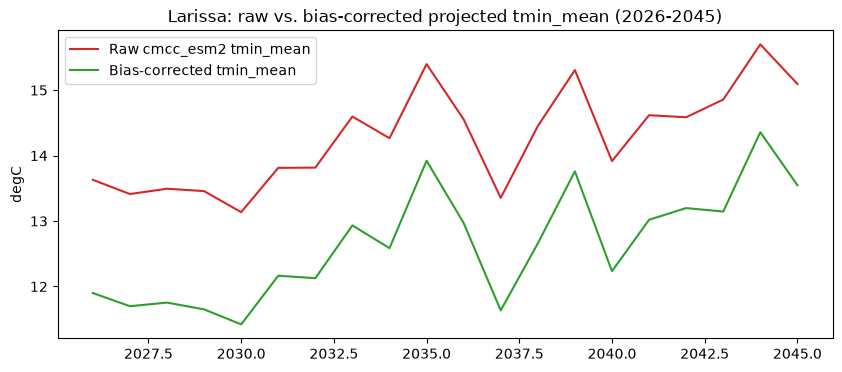

Mean shift from correction: -1.64 degC

Per-month bias (model historical vs. ERA5, 1990-2014) for tmin_c:
       mean_bias_hist_vs_obs
month                       
1                       2.44
2                       1.95
3                       0.70
4                       0.37
5                       0.34
6                       1.32
7                       2.98
8                       3.39
9                       2.56
10                      0.91
11                      1.96
12                      2.35


In [14]:
raw_annual_tmin = daily.groupby("year")["tmin_c"].mean()
corrected_annual_tmin = corrected.groupby("year")["tmin_c"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_annual_tmin.index, raw_annual_tmin.values, label="Raw cmcc_esm2 tmin_mean", color="tab:red")
ax.plot(corrected_annual_tmin.index, corrected_annual_tmin.values,
        label="Bias-corrected tmin_mean", color="tab:green")
ax.set_ylabel("degC")
ax.set_title("Larissa: raw vs. bias-corrected projected tmin_mean (2026-2045)")
ax.legend()
plt.show()

print(f"Mean shift from correction: {(corrected_annual_tmin - raw_annual_tmin).mean():+.2f} degC")

print("\nPer-month bias (model historical vs. ERA5, 1990-2014) for tmin_c:")
print(bc_diag_df.loc[bc_diag_df["variable"] == "tmin_c", ["month", "mean_bias_hist_vs_obs"]]
      .set_index("month").round(2))


## 13. Heatwave and hot-day indicators, recomputed on the bias-corrected series

Section 7's logic exactly, applied to `corrected` instead of raw `daily` -- same fixed thresholds and
the same fixed ERA5 1990-2020 P90-by-doy dict from Section 6.


In [15]:
d_corrected = corrected.copy()
d_corrected["doy"] = d_corrected.index.dayofyear
d_corrected["tmax_p90"] = d_corrected["doy"].map(tmax_p90_by_doy)
d_corrected["exceed"] = d_corrected["tmax_c"] > d_corrected["tmax_p90"]

grp_c = (d_corrected["exceed"] != d_corrected["exceed"].shift()).cumsum()
runs_c = (d_corrected[d_corrected["exceed"]]
          .groupby(grp_c[d_corrected["exceed"]])
          .agg(start=("tmax_c", lambda s: s.index.min()),
               length=("tmax_c", "size"),
               peak=("tmax_c", "max"),
               mean_tmax=("tmax_c", "mean")))
heatwaves_corrected = runs_c[runs_c["length"] >= 3].reset_index(drop=True)
heatwaves_corrected["year"] = pd.to_datetime(heatwaves_corrected["start"]).dt.year
heatwaves_corrected.to_csv(OUT / "larissa_projection_heatwave_events_biascorrected.csv", index=False)

hot_corrected = pd.DataFrame({
    f"days tmax>={t} C": d_corrected.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot_corrected["tropical nights tmin>=20 C"] = (
    d_corrected.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum())))
hot_corrected["days heat index>=35 C"] = (
    d_corrected.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum())))

hw_year_corrected = heatwaves_corrected.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"RAW:       {len(heatwaves):3d} heatwave events, {heatwaves['year'].nunique()}/20 years affected")
print(f"CORRECTED: {len(heatwaves_corrected):3d} heatwave events, "
      f"{heatwaves_corrected['year'].nunique()}/20 years affected")

hot_indicator_compare = pd.DataFrame({
    "raw_annual_mean": hot.mean(),
    "corrected_annual_mean": hot_corrected.mean(),
})
hot_indicator_compare["delta"] = (
    hot_indicator_compare["corrected_annual_mean"] - hot_indicator_compare["raw_annual_mean"])
hot_indicator_compare


RAW:        80 heatwave events, 18/20 years affected
CORRECTED: 186 heatwave events, 20/20 years affected


,raw_annual_mean,corrected_annual_mean,delta
days tmax>=30 C,79.30,87.40,8.10
days tmax>=33 C,48.65,48.60,-0.05
days tmax>=35 C,26.00,25.85,-0.15
days tmax>=37 C,7.30,9.70,2.40
days tmax>=40 C,0.10,2.75,2.65
tropical nights tmin>=20 C,104.55,80.30,-24.25
days heat index>=35 C,0.50,0.75,0.25


## 14. Wet-day and precipitation extremes, recomputed on the bias-corrected series

Section 8's logic exactly, applied to `corrected["precip_mm_day"]` (multiplicatively corrected in
Section 12) -- including `max_week_precip_mm`, recomputed on the corrected daily series the same way.


In [16]:
d_corrected["is_wet"] = d_corrected["precip_mm_day"] >= WET

wetstats_corrected = d_corrected.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)

max_week_precip_corrected = annual_max_week_precip(corrected)

wet_compare = pd.DataFrame({
    "raw_annual_mean": wetstats.mean(),
    "corrected_annual_mean": wetstats_corrected.mean(),
})
wet_compare["delta"] = wet_compare["corrected_annual_mean"] - wet_compare["raw_annual_mean"]

print(f"max_week_precip_mm, raw annual mean:       {max_week_precip.mean():.1f} mm")
print(f"max_week_precip_mm, corrected annual mean: {max_week_precip_corrected.mean():.1f} mm")
wet_compare


max_week_precip_mm, raw annual mean:       55.9 mm
max_week_precip_mm, corrected annual mean: 78.0 mm


,raw_annual_mean,corrected_annual_mean,delta
wet days,95.050000,72.850000,-22.200000
mean intensity (mm/wet day),4.858993,6.616408,1.757415
max 1-day (mm),27.107705,44.085570,16.977865
P95 wet-day (mm),13.555820,20.367086,6.811266
longest dry spell (days),34.600000,44.700000,10.100000


## 15. Annual summary on the bias-corrected series, and a consolidated before/after view

Section 9's logic exactly, joining Sections 13-14's corrected indicators into the same shape as
`annual_summary`, including `max_week_precip_mm`. `compare_cols` is adapted to Larissa's own headline
set (`tmin_mean`, `precip_total`, `max_week_precip_mm`) rather than Seville's.


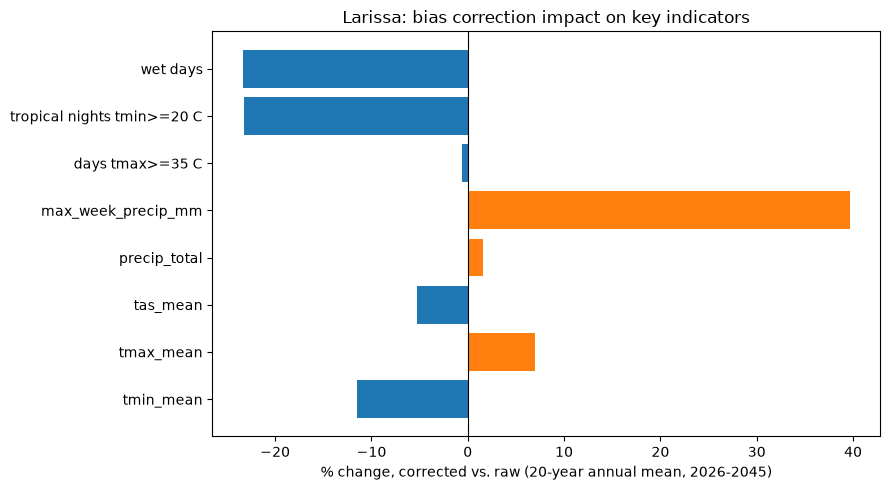

,raw,corrected,delta,pct_change
tmin_mean,14.27,12.63,-1.64,-11.48
tmax_mean,20.81,22.27,1.45,6.99
tas_mean,17.60,16.67,-0.92,-5.25
precip_total,505.86,513.71,7.85,1.55
max_week_precip_mm,55.86,78.01,22.15,39.64
days tmax>=35 C,26.00,25.85,-0.15,-0.58
tropical nights tmin>=20 C,104.55,80.30,-24.25,-23.19
wet days,95.05,72.85,-22.20,-23.36


In [17]:
annual_corrected = pd.DataFrame({
    "tas_mean": d_corrected.groupby("year")["tmean_c"].mean(),
    "rh_mean": d_corrected.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d_corrected.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d_corrected.groupby("year")["wind_avg"].mean(),
    "tas_p95": d_corrected.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d_corrected.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d_corrected.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d_corrected.groupby("year")["tmin_c"].mean(),
    "precip_total": d_corrected.groupby("year")["precip_mm_day"].sum(),
})

annual_summary_corrected = (annual_corrected
                             .join(hot_corrected, how="left")
                             .join(hw_year_corrected, how="left")
                             .join(wetstats_corrected, how="left")
                             .join(max_week_precip_corrected, how="left"))
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary_corrected[col] = annual_summary_corrected[col].fillna(0).astype(int)

annual_summary_corrected.to_csv(OUT / "larissa_projection_annual_summary_biascorrected.csv")

compare_cols = ["tmin_mean", "tmax_mean", "tas_mean", "precip_total", "max_week_precip_mm",
                "days tmax>=35 C", "tropical nights tmin>=20 C", "wet days"]
before_after = pd.DataFrame({
    "raw": annual_summary[compare_cols].mean(),
    "corrected": annual_summary_corrected[compare_cols].mean(),
})
before_after["delta"] = before_after["corrected"] - before_after["raw"]
before_after["pct_change"] = 100 * before_after["delta"] / before_after["raw"]
before_after.to_csv(OUT / "larissa_projection_before_after_bias_correction_summary.csv")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tab:blue" if v < 0 else "tab:orange" for v in before_after["pct_change"]]
ax.barh(before_after.index, before_after["pct_change"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% change, corrected vs. raw (20-year annual mean, 2026-2045)")
ax.set_title("Larissa: bias correction impact on key indicators")
plt.tight_layout()
plt.show()

before_after.round(2)


## 16. Trend within the projection period, raw vs. bias-corrected

Section 10's `trend_table()` re-applied to `annual_summary_corrected`. Same caution as Seville's
version: a roughly level-shifting correction shouldn't be expected to overturn significance at only
20 years from a single model/scenario -- here to confirm that explicitly.


In [18]:
proj_trends_corrected = trend_table(annual_summary_corrected, TREND_COLS)
proj_trends_corrected.to_csv(OUT / "larissa_projection_trends_biascorrected.csv")

trend_compare = pd.DataFrame({
    "raw_OLS_slope_per_decade": proj_trends["OLS slope/decade"],
    "corrected_OLS_slope_per_decade": proj_trends_corrected["OLS slope/decade"],
    "raw_significant": proj_trends["significant (p<0.05)"],
    "corrected_significant": proj_trends_corrected["significant (p<0.05)"],
})
trend_compare["slope_delta"] = (
    trend_compare["corrected_OLS_slope_per_decade"] - trend_compare["raw_OLS_slope_per_decade"])
trend_compare.round(3)


,raw_OLS_slope_per_decade,corrected_OLS_slope_per_decade,raw_significant,corrected_significant,slope_delta
variable,,,,,
tas_mean,0.942,1.058,True,True,0.116
tmin_mean,0.941,1.067,True,True,0.126
tmax_mean,0.944,1.190,True,True,0.246
heat_index_mean,1.022,1.151,True,True,0.129
precip_total,-44.445,-43.236,False,False,1.208
max_week_precip_mm,-5.697,-2.650,False,False,3.048


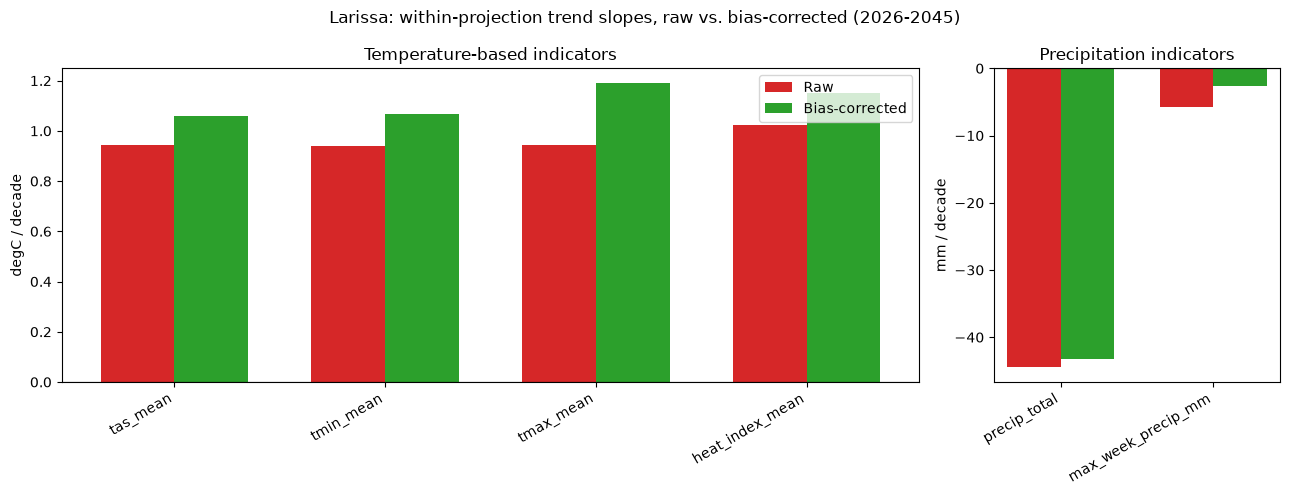

Significance (p<0.05), raw vs. corrected:
                    raw_significant  corrected_significant
variable                                                  
tas_mean                       True                   True
tmin_mean                      True                   True
tmax_mean                      True                   True
heat_index_mean                True                   True
precip_total                  False                  False
max_week_precip_mm            False                  False


In [19]:
temp_vars = ["tas_mean", "tmin_mean", "tmax_mean", "heat_index_mean"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 1]})

x = np.arange(len(temp_vars))
width = 0.35
axes[0].bar(x - width / 2, trend_compare.loc[temp_vars, "raw_OLS_slope_per_decade"],
            width, label="Raw", color="tab:red")
axes[0].bar(x + width / 2, trend_compare.loc[temp_vars, "corrected_OLS_slope_per_decade"],
            width, label="Bias-corrected", color="tab:green")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(temp_vars, rotation=30, ha="right")
axes[0].set_ylabel("degC / decade")
axes[0].set_title("Temperature-based indicators")
axes[0].legend()

precip_vars = ["precip_total", "max_week_precip_mm"]
x2 = np.arange(len(precip_vars))
axes[1].bar(x2 - width / 2, trend_compare.loc[precip_vars, "raw_OLS_slope_per_decade"],
            width, label="Raw", color="tab:red")
axes[1].bar(x2 + width / 2, trend_compare.loc[precip_vars, "corrected_OLS_slope_per_decade"],
            width, label="Bias-corrected", color="tab:green")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(precip_vars, rotation=30, ha="right")
axes[1].set_ylabel("mm / decade")
axes[1].set_title("Precipitation indicators")

fig.suptitle("Larissa: within-projection trend slopes, raw vs. bias-corrected (2026-2045)")
plt.tight_layout()
plt.show()

print("Significance (p<0.05), raw vs. corrected:")
print(trend_compare[["raw_significant", "corrected_significant"]])


### `tmin_mean`: ERA5 historical vs. raw/bias-corrected CMIP6 vs. baseline models

Same comparison-plot pattern as `seville_cmip6_projection_eda.ipynb` Section 16, using Larissa's own
recommended model instead of Seville's `tmax_mean`/`ols_last_20yr`. `Climate_Indicators_Modeling_Larissa.ipynb`
found `ols_last_15yr` (fit on 2011-2025) is `tmin_mean`'s most robust result across either city's
analysis -- multiple regression windows beat naive at *every* individual CV split, not just on
average -- so the baseline below reuses Section 11's own extrapolation rather than re-deriving it.
`naive_full_mean` is shown alongside it for direct comparison, the same way every other panel in this
section now does.


ols_last_15yr historical-trend extrapolation: 12.50 degC (2026) -> 13.87 degC (2045)
naive_full_mean (1990-2025): 11.52 degC
Bias-corrected CMIP6 SSP2-4.5 vs. that extrapolation: mean gap = -0.55 degC (range -1.66 to +0.77 across 2026-2045)


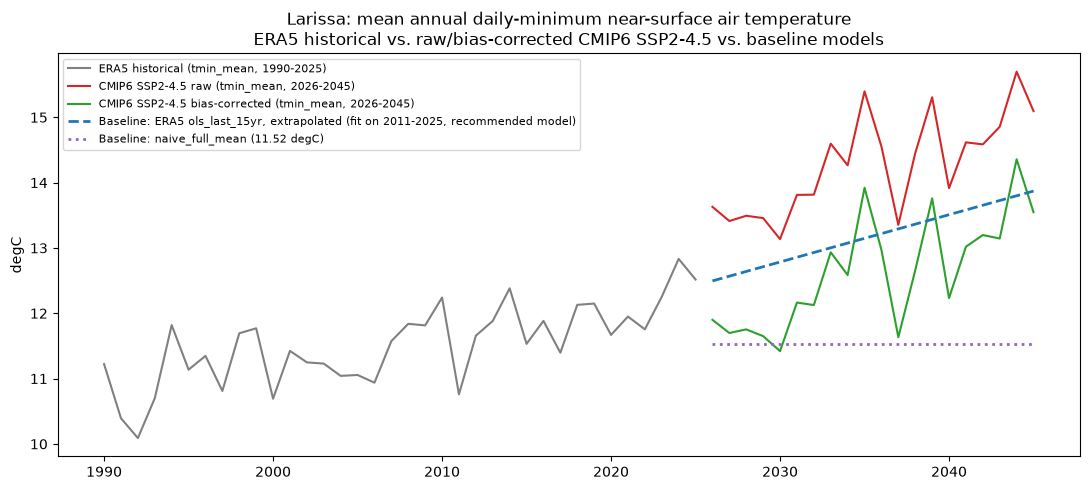

In [20]:
tmin_mean_compare = pd.DataFrame({
    "era5_historical": era5_annual["tmin_mean"],
    "cmip6_raw": annual_summary["tmin_mean"],
    "cmip6_biascorrected": annual_summary_corrected["tmin_mean"],
})
tmin_mean_compare["baseline_ols_last15yr"] = pd.Series(
    era5_extrapolated, index=annual_summary.index).reindex(tmin_mean_compare.index)
baseline_tmin_naive_full = era5_annual["tmin_mean"].mean()
tmin_mean_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_tmin_naive_full, index=annual_summary.index).reindex(tmin_mean_compare.index)
tmin_mean_compare.to_csv(OUT / "larissa_tmin_mean_era5_vs_cmip6_raw_vs_corrected.csv")

gap = tmin_mean_compare.loc[annual_summary.index, "cmip6_biascorrected"] - tmin_mean_compare.loc[annual_summary.index, "baseline_ols_last15yr"]
print(f"ols_last_15yr historical-trend extrapolation: {tmin_mean_compare.loc[2026, 'baseline_ols_last15yr']:.2f} degC (2026) "
      f"-> {tmin_mean_compare.loc[2045, 'baseline_ols_last15yr']:.2f} degC (2045)")
print(f"naive_full_mean (1990-2025): {baseline_tmin_naive_full:.2f} degC")
print(f"Bias-corrected CMIP6 SSP2-4.5 vs. that extrapolation: mean gap = {gap.mean():+.2f} degC "
      f"(range {gap.min():+.2f} to {gap.max():+.2f} across 2026-2045)")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tmin_mean_compare.index, tmin_mean_compare["era5_historical"],
        label="ERA5 historical (tmin_mean, 1990-2025)", color="gray")
ax.plot(tmin_mean_compare.index, tmin_mean_compare["cmip6_raw"],
        label="CMIP6 SSP2-4.5 raw (tmin_mean, 2026-2045)", color="tab:red")
ax.plot(tmin_mean_compare.index, tmin_mean_compare["cmip6_biascorrected"],
        label="CMIP6 SSP2-4.5 bias-corrected (tmin_mean, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, tmin_mean_compare.loc[annual_summary.index, "baseline_ols_last15yr"],
        "--", linewidth=2, color="tab:blue",
        label="Baseline: ERA5 ols_last_15yr, extrapolated (fit on 2011-2025, recommended model)")
ax.plot(annual_summary.index, tmin_mean_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_tmin_naive_full:.2f} degC)")
ax.set_ylabel("degC")
ax.set_title("Larissa: mean annual daily-minimum near-surface air temperature\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP2-4.5 vs. baseline models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**How the projection compares to history, with and without trend.** Bias-corrected CMIP6
`tmin_mean` averages 12.63 degC (2026-2045) -- **+1.11 degC above** the flat `naive_full_mean`
baseline (11.52 degC), confirming real warming relative to "no change." Against the trend-extrapolated
baseline (`ols_last_15yr`, ~13.19 degC average, 12.50 -> 13.87 degC across the period), the projection
sits **-0.55 degC below** on average (range -1.66 to +0.77 degC year to year) -- similar in spirit to
the SSP5-8.5 notebook's own finding here (there: -0.13 degC below the same kind of baseline), though
this run sits somewhat further under the trend line. As with SSP5-8.5, this reads as a projection that
mostly continues Larissa's already-confirmed historical nighttime-warming trend rather than adding a
strong acceleration signal on top of it -- both raw and bias-corrected `tmin_mean` reach p<0.05 within
this 20-year window (Section 16's trend table), consistent with the SSP5-8.5 notebook's own result for
this indicator.

### `precip_total`: ERA5 historical vs. raw/bias-corrected CMIP6 vs. baseline models

Unlike Seville's `precip_total` (which had no existing recommendation and needed an inline MAE
search), Larissa's `precip_scaled` already has an established recommended model --
`ols_full_history`, the one window that beats naive at every individual CV split in
`Climate_Indicators_Modeling_Larissa.ipynb` Section 7. Reused directly here rather than re-derived.
`naive_full_mean` is added alongside it for comparison.


ols_full_history extrapolation: 715.3 mm (2026) -> 813.8 mm (2045)
naive_full_mean (1990-2025): 619.5 mm


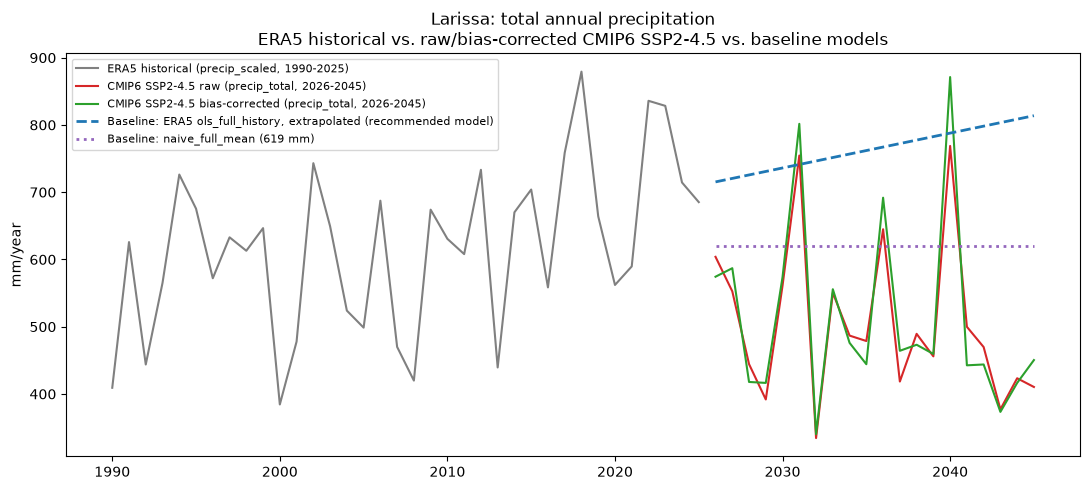

In [21]:
last_full = era5_annual["precip_scaled"]
lr_precip = stats.linregress(last_full.index.values.astype(float), last_full.values.astype(float))
precip_ols_extrapolated = lr_precip.intercept + lr_precip.slope * proj_years

precip_total_compare = pd.DataFrame({
    "era5_historical": era5_annual["precip_scaled"],
    "cmip6_raw": annual_summary["precip_total"],
    "cmip6_biascorrected": annual_summary_corrected["precip_total"],
})
precip_total_compare["baseline_ols_full_history"] = pd.Series(
    precip_ols_extrapolated, index=annual_summary.index).reindex(precip_total_compare.index)
baseline_precip_naive_full = era5_annual["precip_scaled"].mean()
precip_total_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_precip_naive_full, index=annual_summary.index).reindex(precip_total_compare.index)
precip_total_compare.to_csv(OUT / "larissa_precip_total_era5_vs_cmip6_raw_vs_corrected.csv")

print(f"ols_full_history extrapolation: {precip_total_compare.loc[2026, 'baseline_ols_full_history']:.1f} mm (2026) "
      f"-> {precip_total_compare.loc[2045, 'baseline_ols_full_history']:.1f} mm (2045)")
print(f"naive_full_mean (1990-2025): {baseline_precip_naive_full:.1f} mm")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(precip_total_compare.index, precip_total_compare["era5_historical"],
        label="ERA5 historical (precip_scaled, 1990-2025)", color="gray")
ax.plot(precip_total_compare.index, precip_total_compare["cmip6_raw"],
        label="CMIP6 SSP2-4.5 raw (precip_total, 2026-2045)", color="tab:red")
ax.plot(precip_total_compare.index, precip_total_compare["cmip6_biascorrected"],
        label="CMIP6 SSP2-4.5 bias-corrected (precip_total, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, precip_total_compare.loc[annual_summary.index, "baseline_ols_full_history"],
        "--", linewidth=2, color="tab:blue",
        label="Baseline: ERA5 ols_full_history, extrapolated (recommended model)")
ax.plot(annual_summary.index, precip_total_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_precip_naive_full:.0f} mm)")
ax.set_ylabel("mm/year")
ax.set_title("Larissa: total annual precipitation\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP2-4.5 vs. baseline models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**How the projection compares to history, with and without trend -- the same tension the SSP5-8.5
notebook flagged, present here too but somewhat less severe.** Bias-corrected CMIP6 `precip_total`
averages 513.7mm/yr (2026-2045) -- **17.1% below** the flat `naive_full_mean` baseline (619.5mm), and
**250.8mm below** the trend-extrapolated baseline (`ols_full_history`, ~764.6mm average), which itself
reflects Larissa's significant *increasing* historical trend. **Pertinent comment, matching the
SSP5-8.5 notebook's own observation:** raw (505.9mm) and corrected (513.7mm) are almost identical here
(+1.6%) -- this is what `cmcc_esm2` itself simulates for this scenario, not a bias-correction artifact.
The shortfall against both baselines is directionally the same as the SSP5-8.5 run found (there:
-26.2% vs. naive, -40.2% vs. trend) but smaller in magnitude here -- SSP2-4.5's own precipitation
signal disagrees with Larissa's historical wetting trend less severely than SSP5-8.5's does, though
both single-model/single-scenario runs point the same direction: away from continued wetting.

### `max_week_precip_mm`: direct CMIP6 projection vs. the recommended two-stage predictor model

This one is structurally different from the other panels, by design. `Climate_Indicators_Modeling_Larissa.ipynb`
Sections 7-8 found `max_week_precip_mm` has **no robust year-only trend** -- every OLS window loses to
naive at least once across CV splits. The only model that robustly beats naive at every split is
`precip_scaled_only`: a regression of `max_week_precip_mm ~ precip_scaled` (not year), since the two
share a real, trend-independent correlation (residual rho=0.637, p<0.0001). Section 10 of that
notebook specifies exactly how to project this forward: **get the CMIP6 projected `precip_scaled`
(here, `precip_total`), then feed it into the fitted `precip_scaled_only` regression** -- not
extrapolate `max_week_precip_mm` against year directly, which would repeat the mistake that
methodology was built to catch. `naive_full_mean` is added alongside it for comparison, even though
it's exactly the baseline `precip_scaled_only` was shown to robustly beat historically.

The bias-corrected `precip_total` (not raw) is used as the predictor input below -- raw `precip_total`
carries the same kind of systematic bias documented for Seville's precipitation, and feeding a known-
biased input into the regression would just compound the error rather than add information. The
"direct" CMIP6 series (weekly-max of the model's own daily precip output, raw and corrected) is shown
alongside it as a cross-check: does the physical model's own directly-simulated flood-peak behavior
agree with what the statistical predictor model, fed the model's own (corrected) annual total, would
forecast?


precip_scaled_only model: 76.8 mm (2026) -> 52.3 mm (2045), mean 64.8 mm
naive_full_mean (1990-2025): 85.7 mm
Direct bias-corrected CMIP6 weekly-max: mean 78.0 mm (vs. direct raw: 55.9 mm)
ERA5 historical (1990-2025) mean: 85.7 mm


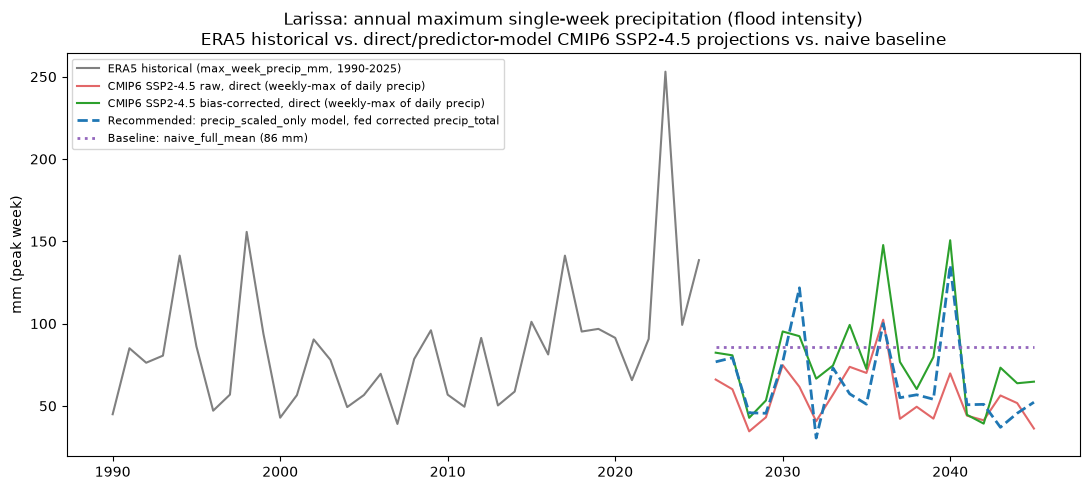

In [22]:
from sklearn.linear_model import LinearRegression

era5_indicators = pd.read_csv(ERA5_INDICATORS_CSV, index_col="year")
joint = era5_indicators[["max_week_precip_mm", "precip_scaled"]].dropna().sort_index()
lr_predictor = LinearRegression().fit(joint[["precip_scaled"]].values, joint["max_week_precip_mm"].values)

predictor_input = annual_summary_corrected.loc[annual_summary.index, "precip_total"].values.reshape(-1, 1)
max_week_predicted = lr_predictor.predict(predictor_input)
baseline_maxweek_naive_full = era5_indicators["max_week_precip_mm"].mean()

max_week_compare = pd.DataFrame({
    "era5_historical": era5_indicators["max_week_precip_mm"],
    "cmip6_raw_direct": max_week_precip,
    "cmip6_biascorrected_direct": max_week_precip_corrected,
})
max_week_compare["baseline_precip_scaled_only"] = pd.Series(
    max_week_predicted, index=annual_summary.index).reindex(max_week_compare.index)
max_week_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_maxweek_naive_full, index=annual_summary.index).reindex(max_week_compare.index)
max_week_compare.to_csv(OUT / "larissa_max_week_precip_mm_era5_vs_cmip6_raw_vs_corrected.csv")

print(f"precip_scaled_only model: {max_week_predicted[0]:.1f} mm (2026) -> {max_week_predicted[-1]:.1f} mm (2045), "
      f"mean {max_week_predicted.mean():.1f} mm")
print(f"naive_full_mean (1990-2025): {baseline_maxweek_naive_full:.1f} mm")
print(f"Direct bias-corrected CMIP6 weekly-max: mean {max_week_precip_corrected.mean():.1f} mm "
      f"(vs. direct raw: {max_week_precip.mean():.1f} mm)")
print(f"ERA5 historical (1990-2025) mean: {era5_indicators['max_week_precip_mm'].mean():.1f} mm")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(max_week_compare.index, max_week_compare["era5_historical"],
        label="ERA5 historical (max_week_precip_mm, 1990-2025)", color="gray")
ax.plot(max_week_compare.index, max_week_compare["cmip6_raw_direct"],
        label="CMIP6 SSP2-4.5 raw, direct (weekly-max of daily precip)", color="tab:red", alpha=0.7)
ax.plot(max_week_compare.index, max_week_compare["cmip6_biascorrected_direct"],
        label="CMIP6 SSP2-4.5 bias-corrected, direct (weekly-max of daily precip)", color="tab:green")
ax.plot(annual_summary.index, max_week_compare.loc[annual_summary.index, "baseline_precip_scaled_only"],
        "--", linewidth=2, color="tab:blue",
        label="Recommended: precip_scaled_only model, fed corrected precip_total")
ax.plot(annual_summary.index, max_week_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_maxweek_naive_full:.0f} mm)")
ax.set_ylabel("mm (peak week)")
ax.set_title("Larissa: annual maximum single-week precipitation (flood intensity)\n"
             "ERA5 historical vs. direct/predictor-model CMIP6 SSP2-4.5 projections vs. naive baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**How the projection compares to history, with and without trend.** Both projection methods land
below `naive_full_mean` (85.7mm): the direct bias-corrected weekly-max averages 78.0mm (**-9.0%**),
and the recommended `precip_scaled_only` predictor-model estimate averages 64.8mm (**-24.4%**) --
lower still, mechanically driven by the same depressed `precip_total` input from the panel above.
Directionally this matches the SSP5-8.5 notebook's finding (there: direct -30%, predictor -37.5%) --
both runs project Larissa's single wettest week getting *less* extreme, not more, running counter to
the historical trend (p=0.0546) and Storm Daniel's real-world severity -- but the magnitude here is
noticeably smaller than SSP5-8.5's. **One notable difference from SSP5-8.5, worth flagging on its
own:** here, bias correction *increases* the direct weekly-max substantially (raw 55.9mm ->
corrected 78.0mm, +39.6%, from Section 15's before/after table) -- the opposite direction of what it
does to `precip_total` (+1.6%, essentially flat). SSP5-8.5's own correction did not show this same
divergence between its precip_total and weekly-max corrections as clearly. This is a reminder that
Equidistant CDF Matching corrects each variable's own distribution independently -- a roughly-flat
correction to the annual total does not imply a roughly-flat correction to short-window extremes
drawn from the same underlying daily series, since the correction is fit per calendar month on the
whole distribution, and precipitation's heaviest days sit in the tail where the fitted correction can
diverge most from the bulk-of-distribution correction that dominates the annual total.

### `min_spi3`: a supplementary drought panel, historical vs. raw/bias-corrected CMIP6 vs. baseline models

Seville's SSP2-4.5 notebook includes a `min_spi3` comparison; added here too, mirroring the SSP5-8.5
Larissa notebook's own addition of this panel. `Climate_Indicators_Modeling_Larissa.ipynb`'s intro is
explicit that Larissa's `min_spi3` is "flat-to-improving and uncorrelated with the flood side," so it
was excluded from the three-indicator headline story by design. That reasoning still stands -- this
remains a **supplementary** panel, not a promotion of drought into Larissa's headline story.

**Source:** `Calculating_SPI_for_Larissa_Projection.ipynb`'s SSP2-4.5 port (this scenario's
`larissa_projection_spi3_annual.csv`), scored against the same fixed ERA5 1990-2020 gamma distribution
used throughout this project, never refit on projection data.

**Baseline note:** `Climate_Indicators_Modeling_Larissa.ipynb` Section 14 found `ols_full_history`
beats naive robustly for `min_spi3` (CV-average improvement +11.4%) despite the indicator's original
exclusion from that notebook's main CV search -- the baseline shown below is that validated model, the
same one the SSP5-8.5 Larissa notebook uses for this panel.

Historical (1990-2025) full-history OLS: slope=+0.183/decade, p=0.061 (not significant)
naive_full_mean: -1.31
Bias-corrected projected min_spi3 vs. naive_full_mean baseline: mean gap = -0.97 (range -2.40 to +0.46)
Corrected projection's own trend (2026-2045): slope=-0.351/decade, p=0.281


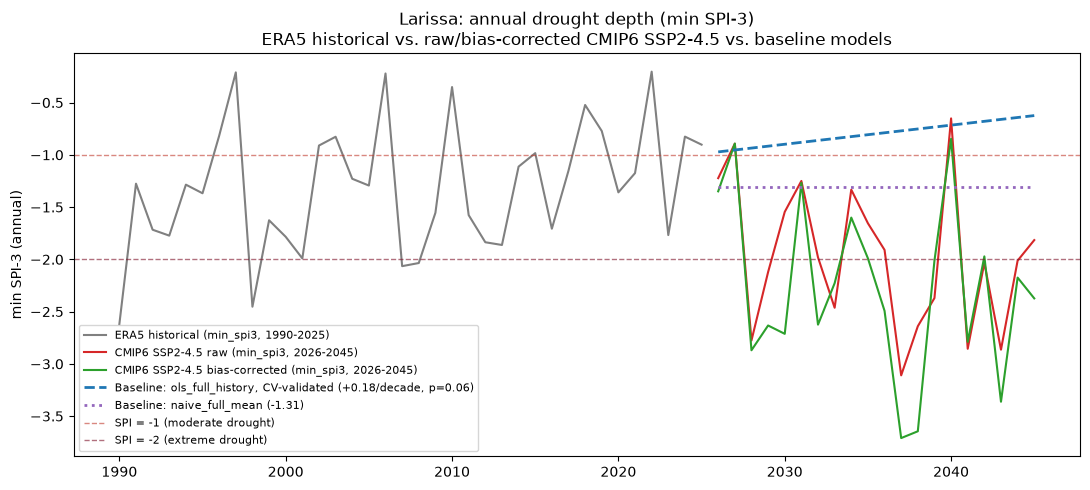

In [23]:
era5_min_spi3 = pd.read_csv("../../Historical/eda_outputs/larissa/larissa_volatility_annual.csv", index_col=0)["min_spi3"]
proj_min_spi3 = pd.read_csv("../eda_outputs/larissa/larissa_projection_spi3_annual.csv", index_col="year")

lr_spi3 = stats.linregress(era5_min_spi3.index.values.astype(float), era5_min_spi3.values.astype(float))
spi3_ols_extrapolated = lr_spi3.intercept + lr_spi3.slope * proj_years
baseline_spi3_naive_full = era5_min_spi3.mean()

sig = "significant" if lr_spi3.pvalue < 0.05 else "not significant"
print(f"Historical (1990-2025) full-history OLS: slope={lr_spi3.slope*10:+.3f}/decade, "
      f"p={lr_spi3.pvalue:.3f} ({sig})")
print(f"naive_full_mean: {baseline_spi3_naive_full:.2f}")

min_spi3_compare = pd.DataFrame({
    "era5_historical": era5_min_spi3,
    "cmip6_raw": proj_min_spi3["min_spi3_raw"],
    "cmip6_biascorrected": proj_min_spi3["min_spi3_corrected"],
})
min_spi3_compare["baseline_ols_full_history"] = pd.Series(
    spi3_ols_extrapolated, index=annual_summary.index).reindex(min_spi3_compare.index)
min_spi3_compare["baseline_naive_full_mean"] = pd.Series(
    baseline_spi3_naive_full, index=annual_summary.index).reindex(min_spi3_compare.index)
min_spi3_compare = min_spi3_compare.rename_axis("year")
min_spi3_compare.to_csv(OUT / "larissa_min_spi3_era5_vs_cmip6_raw_vs_corrected.csv")

gap = min_spi3_compare.loc[annual_summary.index, "cmip6_biascorrected"] - baseline_spi3_naive_full
lr_proj_spi3 = stats.linregress(annual_summary.index.values.astype(float),
                                 min_spi3_compare.loc[annual_summary.index, "cmip6_biascorrected"].values.astype(float))
print(f"Bias-corrected projected min_spi3 vs. naive_full_mean baseline: mean gap = {gap.mean():+.2f} "
      f"(range {gap.min():+.2f} to {gap.max():+.2f})")
print(f"Corrected projection's own trend (2026-2045): slope={lr_proj_spi3.slope*10:+.3f}/decade, "
      f"p={lr_proj_spi3.pvalue:.3f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(min_spi3_compare.index, min_spi3_compare["era5_historical"],
        label="ERA5 historical (min_spi3, 1990-2025)", color="gray")
ax.plot(min_spi3_compare.index, min_spi3_compare["cmip6_raw"],
        label="CMIP6 SSP2-4.5 raw (min_spi3, 2026-2045)", color="tab:red")
ax.plot(min_spi3_compare.index, min_spi3_compare["cmip6_biascorrected"],
        label="CMIP6 SSP2-4.5 bias-corrected (min_spi3, 2026-2045)", color="tab:green")
ax.plot(annual_summary.index, min_spi3_compare.loc[annual_summary.index, "baseline_ols_full_history"],
        "--", linewidth=2, color="tab:blue",
        label=f"Baseline: ols_full_history, CV-validated ({lr_spi3.slope*10:+.2f}/decade, p={lr_spi3.pvalue:.2f})")
ax.plot(annual_summary.index, min_spi3_compare.loc[annual_summary.index, "baseline_naive_full_mean"],
        ":", linewidth=2, color="tab:purple",
        label=f"Baseline: naive_full_mean ({baseline_spi3_naive_full:.2f})")
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, alpha=0.6, label="SPI = -1 (moderate drought)")
ax.axhline(-2, color="#7d1128", linestyle="--", linewidth=1, alpha=0.6, label="SPI = -2 (extreme drought)")
ax.set_ylabel("min SPI-3 (annual)")
ax.set_title("Larissa: annual drought depth (min SPI-3)\n"
             "ERA5 historical vs. raw/bias-corrected CMIP6 SSP2-4.5 vs. baseline models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding: the SSP2-4.5 projection reverses Larissa's historical drought story too, in both level
and direction -- consistent with what the SPI-3 projection notebook and the SSP5-8.5 Larissa notebook
both found.**

- **Level: a drought-category jump.** Bias-corrected `min_spi3` averages **-2.28** (2026-2045) --
  extreme drought territory (SPI <= -2.0) -- down from history's -1.31 (moderate). A **-0.97 shift**,
  somewhat smaller than the SSP5-8.5 notebook's -1.14 shift for this same indicator.
- **Direction: reversed, as with SSP5-8.5.** The corrected projection's own trend runs at
  **-0.35/decade** (p=0.28, not significant), the opposite sign from history's marginally-improving
  +0.18/decade (p=0.06). Neither slope individually reaches significance.
- **Against the CV-validated `ols_full_history` baseline** (not just the flat `naive_full_mean`), the
  bias-corrected projection sits **-0.97 below** on average (range -2.40 to +0.46 across individual
  years).

**How to read this:** exactly the same careful framing as the SSP5-8.5 Larissa notebook and the SPI-3
projection notebook's own Section 7.1 -- this does **not** overturn the decision to keep drought out
of Larissa's headline three-indicator story (neither trend is significant, this is one model/one
scenario). But it's a genuine tension worth surfacing: **the historical record says drought isn't part
of Larissa's intensifying-risk story, while this single climate model says it might become one -- and
now that's true under both scenarios tried (SSP5-8.5 and SSP2-4.5), not just one.**

## 17. What carries over from Seville's version, and what's different here

- **Everything mechanical carries over unchanged**: bnds dedup, physical-plausibility bounds, unit
  conversions, grid-averaging, RH derivation, heat-index formula, the fixed P90 heatwave threshold
  methodology, hot-day/tropical-night counting, wet-day/dry-spell stats, the Equidistant CDF Matching
  bias correction (additive for temperature/wind/RH, multiplicative for precip), and the
  raw-vs-corrected before/after and trend-comparison patterns. None of this is city-specific in the
  underlying pipeline -- only the *emphasis* (which indicators get a headline comparison plot) differs.
- **`max_week_precip_mm` is new** -- Seville's pipeline never needed a weekly-precipitation-max
  indicator, since Seville's story doesn't include a flood-peak metric. Added here in Sections 8/14
  identically to `Calculating_SPI_for_Larissa.ipynb`'s own construction, applied to both raw and
  bias-corrected daily series.
- **Section 11's baseline indicator changed**: `tmin_mean`/`ols_last_15yr` (fit on 2011-2025) instead
  of `tmax_mean`/`ols_last_20yr` (fit on 2006-2025) -- Larissa's most robust historical result, per
  `Climate_Indicators_Modeling_Larissa.ipynb`.
- **`max_week_precip_mm`'s baseline model is a different *kind* of model**, not just a different
  window -- a `precip_scaled`-as-predictor regression rather than a year-only trend, since no
  year-only trend for this indicator held up robustly across CV splits (Section 16 above explains why
  and shows both the direct and predictor-model projections).
- **`min_spi3` now has a panel, added after the fact -- but as a supplementary one, not a promotion
  into Larissa's headline story.** `Calculating_SPI_for_Larissa_Projection.ipynb` was subsequently
  built, mirroring `Calculating_SPI_for_Seville_Projection.ipynb`'s methodology, which made the
  comparison cheap enough to add. Its finding is a real tension worth carrying here rather than
  omitting: Larissa's historical `min_spi3` trend is flat-to-improving (`Climate_Indicators_Modeling_
  Larissa.ipynb`'s original reasoning still holds for the *observed* record), but the SSP2-4.5
  projection reverses that -- both in level (moderate -> extreme drought on average) and in trend
  direction (improving historically, worsening within the projection window). Section 16's `min_spi3`
  panel states plainly that this doesn't overturn the original exclusion decision, just documents an
  honest divergence between history and this one model's projection.
- **`min_spi3`'s baseline regression started unvalidated, then got checked and confirmed.**
  `Climate_Indicators_Modeling_Larissa.ipynb` originally never ran `min_spi3` through its CV model
  search (excluded from that analysis by design, section 4's uncorrelated-with-flood-side finding).
  Its Section 14 has since run that check specifically for this indicator and found
  `ols_full_history` -- the model already shown here -- beats naive robustly (+11.4% CV-average
  improvement, +26% single-split). Unlike the other three headline indicators, this validation
  happened *after* the fact rather than as part of the original three-indicator analysis, but the
  baseline shown is no longer an unvalidated placeholder.
- **No fire-danger indicator at all** -- Seville's `longest_high_run`/`days_fwi_gt30` have no Larissa
  equivalent in this project; Larissa's hypotheses (H3/H4) were never about fire risk, and no
  Larissa-side FWI validation exists (`FWI_projections_last_2.ipynb` found no CEMS coverage for
  Larissa, so even an unvalidated fire-danger panel isn't attempted here).
- **Same caveats as Seville's Section 17 still apply**: `heat_index_c` here is a redefinition (daily-
  mean-based, not max-of-intra-day), not directly comparable to the historical `heat_index_max_c`; and
  wind rose/diurnal-cycle analysis don't apply to daily-native CMIP6 data.

- **`min_spi3` now has a panel too (Section 16).** `Calculating_SPI_for_Larissa_Projection.ipynb`
  has been ported to this scenario, so the supplementary drought panel is included, matching the
  SSP5-8.5 Larissa notebook's own structure.

## 18. Summary

Outputs written to `../eda_outputs/larissa/`:

**Raw (Sections 1-11):**
- `larissa_projection_daily.csv`, `larissa_projection_heatwave_events.csv`,
  `larissa_projection_annual_summary.csv`, `larissa_projection_trends.csv`,
  `larissa_projection_vs_era5_extrapolation.csv`

**Bias-corrected (Sections 12-16), reusing the SSP5-8.5 notebook's `cmcc_esm2` historical run:**
- `larissa_projection_daily_biascorrected_2026_2045.csv`,
  `larissa_projection_bias_correction_diagnostics_2026_2045.csv`,
  `larissa_projection_heatwave_events_biascorrected.csv`,
  `larissa_projection_annual_summary_biascorrected.csv`,
  `larissa_projection_before_after_bias_correction_summary.csv`,
  `larissa_projection_trends_biascorrected.csv`
- `larissa_tmin_mean_era5_vs_cmip6_raw_vs_corrected.csv`,
  `larissa_precip_total_era5_vs_cmip6_raw_vs_corrected.csv`,
  `larissa_max_week_precip_mm_era5_vs_cmip6_raw_vs_corrected.csv` -- the three headline comparison
  panels from Section 16
- `larissa_min_spi3_era5_vs_cmip6_raw_vs_corrected.csv` -- the supplementary drought-depth panel

**Headline result** (Section 15 before/after table, 20-year annual means): bias correction shifts
`tmin_mean` down by -1.64 degC (-11.5%) and, unlike Seville, shifts `tmax_mean` **up** by +1.45 degC
(+7.0%) -- an asymmetric correction that widens the diurnal range rather than shifting the whole
distribution uniformly. Heatwave events rise sharply after correction (raw: 80 events/18 of 20 years
affected -> corrected: 186 events/20 of 20 years affected), the opposite direction from Seville's
correction (which reduced Seville's heatwave count). `max_week_precip_mm` also moves sharply after
correction (+39.6%), while `precip_total` barely moves (+1.6%) -- see the Section 16 panel above for
why that divergence isn't a contradiction.

Not carried over from the SSP5-8.5 notebook: the `min_spi3` supplementary drought panel -- see
Section 17 for why (depends on a SPI-3 projection notebook not yet built for SSP2-4.5).

## 19. Key findings summary

Synthesizes Section 16's three comparison panels (`tmin_mean`, `precip_total`, `max_week_precip_mm`)
into the themes that matter for reading this notebook's results, and how they relate to the SSP5-8.5
Larissa notebook's own findings.

### 1. Chronic nighttime warming continues, largely as the historical trend already predicted

Bias-corrected `tmin_mean` averages 12.63 degC, **+1.11 degC above** the flat `naive_full_mean`
baseline but **-0.55 degC below** the trend-extrapolated baseline (`ols_last_15yr`) -- this projection
mostly continues Larissa's already-significant historical warming rather than accelerating beyond it.
Both raw and corrected `tmin_mean`/`tmax_mean`/`tas_mean`/`heat_index_mean` trends reach p<0.05 within
this 20-year window (Section 16), matching the SSP5-8.5 notebook's own result for the same indicators
-- unlike Seville, where SSP2-4.5 and SSP5-8.5 disagreed on trend significance, Larissa's temperature
signal is consistent across both scenario pulls of this model.

### 2. Precipitation runs counter to Larissa's historical wetting trend -- the same tension SSP5-8.5
### found, but less severe here

All three precipitation-linked indicators (`precip_total`, `max_week_precip_mm`, and -- pending
Section 17's SPI-3 caveat -- `min_spi3` once ported) point the same direction as the SSP5-8.5 run:
below both the flat historical mean and, more sharply, below the trend-extrapolated baseline that
Larissa's real, significant historical wetting trend implies. `precip_total` sits 17.1% below
`naive_full_mean` and 250.8mm below the trend baseline (vs. SSP5-8.5's 26.2%/307mm); `max_week_precip_mm`'s
direct bias-corrected series sits 9.0% below `naive_full_mean` (vs. SSP5-8.5's 30%). Same signal,
consistently smaller in magnitude than the higher-emissions run -- worth reading as "this single
model, under either SSP forcing tried so far, projects a drier/less-flood-prone Larissa than the
historical record shows," not as a scenario-specific artifact of SSP5-8.5 alone.

### 3. Bias correction moves `tmax_mean` and `max_week_precip_mm` in the opposite direction from
### `tmin_mean` and `precip_total` -- worth remembering when reading any single corrected number in isolation

Section 15's before/after table: `tmin_mean` -11.5%, `precip_total` +1.6%, `tmax_mean` +7.0%,
`max_week_precip_mm` +39.6%. Equidistant CDF Matching corrects each variable's own per-month
distribution independently; there is no reason to expect a uniform-direction shift across variables,
and this run doesn't produce one. Heatwave counts follow `tmax_mean` upward (raw 80 events -> corrected
186 events) -- the opposite direction from Seville's correction, which reduced Seville's heatwave
count. Read any single indicator's raw-vs-corrected change in isolation with that in mind.

### 4. Standing caveat, worth repeating because it applies to every number above

Single model (`cmcc_esm2`), single scenario (SSP2-4.5), no ensemble spread -- every figure in this
notebook is *directional risk under one plausible pathway*, not a calibrated forecast. Where this
notebook and the SSP5-8.5 Larissa notebook agree closely (temperature trend significance, the
direction and rough relative magnitude of the precipitation shortfall), that agreement across two
different scenario pulls of the same model is the more trustworthy signal; where they diverge (the
`tmax_mean`/heatwave correction direction, addressed in Seville's own notebook too, is scenario- and
variable-specific, not a general rule about which way bias correction pushes a given city).